<a href="https://colab.research.google.com/github/AMLU-ANNA-JOSHY/Anomaly_Detection/blob/main/Machine_failure_detection_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data & Problem**

**Dataset (NASA C-MAPSS)**:
The NASA C-MAPSS dataset contains multivariate time-series sensor data from multiple aircraft engines. Each engine is observed over consecutive operating cycles, starting from a healthy state and gradually degrading until failure. For every cycle, the dataset provides operational settings and 21 sensor measurements. Each engine forms an independent sequence with no explicit anomaly labels per timestep.

**Problem**: Detect abnormal or degrading behavior in sequential data.

**Idea**: By learning normal temporal patterns from early, healthy engine cycles, a model can identify departures from normal behavior in later cycles. These deviations are treated as anomalies, indicating the onset of engine degradation.

### **Load Data**

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')


In [ ]:
!kaggle datasets download -d behrad3d/nasa-cmaps
!unzip nasa-cmaps.zip


**Taking FD001 alone**

In [ ]:
import pandas as pd

train_df = pd.read_csv(
    '/content/CMaps/train_FD001.txt',
    sep=' ',
    header = None
)
print(train_df.head())

   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   

   ...       18      19    20   21    22     23     24       25  26  27  
0  ...  8138.62  8.4195  0.03  392  2388  100.0  39.06  23.4190 NaN NaN  
1  ...  8131.49  8.4318  0.03  392  2388  100.0  39.00  23.4236 NaN NaN  
2  ...  8133.23  8.4178  0.03  390  2388  100.0  38.95  23.3442 NaN NaN  
3  ...  8133.83  8.3682  0.03  392  2388  100.0  38.88  23.3739 NaN NaN  
4  ...  8133.80  8.4294  0.03  393  2388  100.0  38.90  23.4044 NaN NaN  

[5 rows x 28 columns]


In [ ]:
# add headers explicitly
columns = (
    ['engine_id', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

# get only these columns, others are NaN, hence removed
train_df = train_df.iloc[:, :len(columns)]
train_df.columns = columns

train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train_df.shape

(20631, 26)

In [ ]:
# use sensor readings alone for training

sensor_cols = [c for c in train_df.columns if 'sensor_' in c]
data = train_df[sensor_cols]

In [ ]:
# normalize data as LSTMs are very sensitive to scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
# inspecting first sample

data_scaled[0]

array([ 0.00000000e+00, -1.72172539e+00, -1.34255176e-01, -9.25935964e-01,
       -1.77635684e-15,  1.41683329e-01,  1.12114057e+00, -5.16338406e-01,
       -8.62813315e-01,  0.00000000e+00, -2.66466596e-01,  3.34261840e-01,
       -1.05889024e+00, -2.69071040e-01, -6.03815700e-01, -1.38777878e-17,
       -7.81709786e-01,  0.00000000e+00,  0.00000000e+00,  1.34849274e+00,
        1.19442705e+00])

In [ ]:
# there are 100 engines' info

train_df['engine_id'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [ ]:
# there are 362 cycles' info at the most

len(train_df['cycle'].unique())

362

In [ ]:
# not all engines have 362 cycles

engine1_data = train_df[train_df['engine_id'] == 1]
len(engine1_data['cycle'].unique())

192

In [ ]:
# Get input in LSTM data format (samples, time_steps, features)
# sliding window is used to consider features for different time stamps
# create a numpy array that holds 30 cycles' information
# take only data of first 200 cylces assuming they are normal or 'healthy'

import numpy as np

def create_healthy_sequences(df, scaled_data, window_size=30, max_cycle=200):
    sequences = []

    for eid in df['engine_id'].unique():
        idx = (df['engine_id'] == eid) & (df['cycle'] <= max_cycle)
        engine_data = scaled_data[idx]

        for i in range(len(engine_data) - window_size):
            sequences.append(engine_data[i:i+window_size])

    return np.array(sequences)

X = create_healthy_sequences(train_df, data_scaled, window_size=30, max_cycle=200)
X.shape

(15627, 30, 21)

In [ ]:
# create 30% validation data
split_idx = int(0.7 * len(X))

X_train = X[:split_idx]
X_val   = X[split_idx:]

In [ ]:
split_idx

10938

In [ ]:
# convert to PyTorch dataset format

import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=64,
    shuffle=True
)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=64,
    shuffle=False # Validation loader is never shuffled
)

### **LSTM Autoencoder for Anomaly Detection**

**Basic Idea:**
- Encoder compresses a sequence → latent vector

- Decoder reconstructs the original sequence

- After training on normal data, during inference if there is a high reconstruction error, it means an anomaly

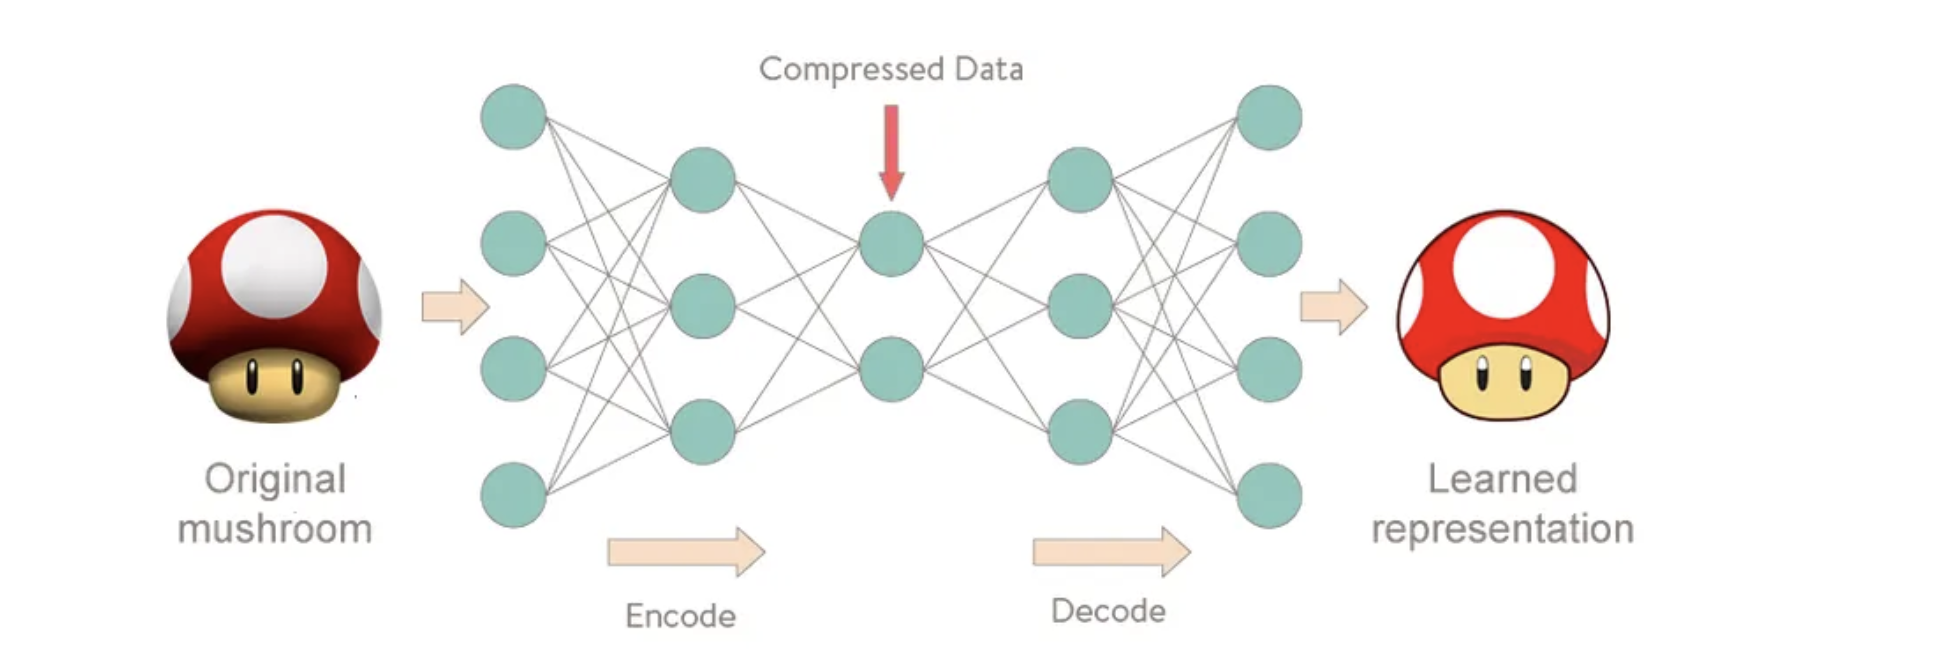

Ref: https://medium.com/@jwbtmf/lstm-autoencoder-for-anomaly-detection-for-ecg-data-5c0b07d00e50

**Architecture:**

- Built using the same basic LSTM architecture, but arranged in an encoder–decoder structure.

- A standard LSTM processes a sequence step by step and maintains a hidden state and cell state to capture long-term temporal dependencies.

- In an LSTM autoencoder, the encoder LSTM reads the input sequence and compresses its temporal information into a fixed-length latent representation (the final hidden state).

- The decoder LSTM takes this latent representation and tries to reconstruct the original input sequence over time.

- The model is trained to minimize reconstruction error, so it learns the normal temporal dynamics of the data.


**Why use for anomaly detection**:

- If a new sequence follows the learned temporal patterns, it is reconstructed well.
- If the sequence deviates from normal behavior, the LSTM cannot reconstruct it accurately, leading to a high reconstruction error, which is used as an anomaly signal.

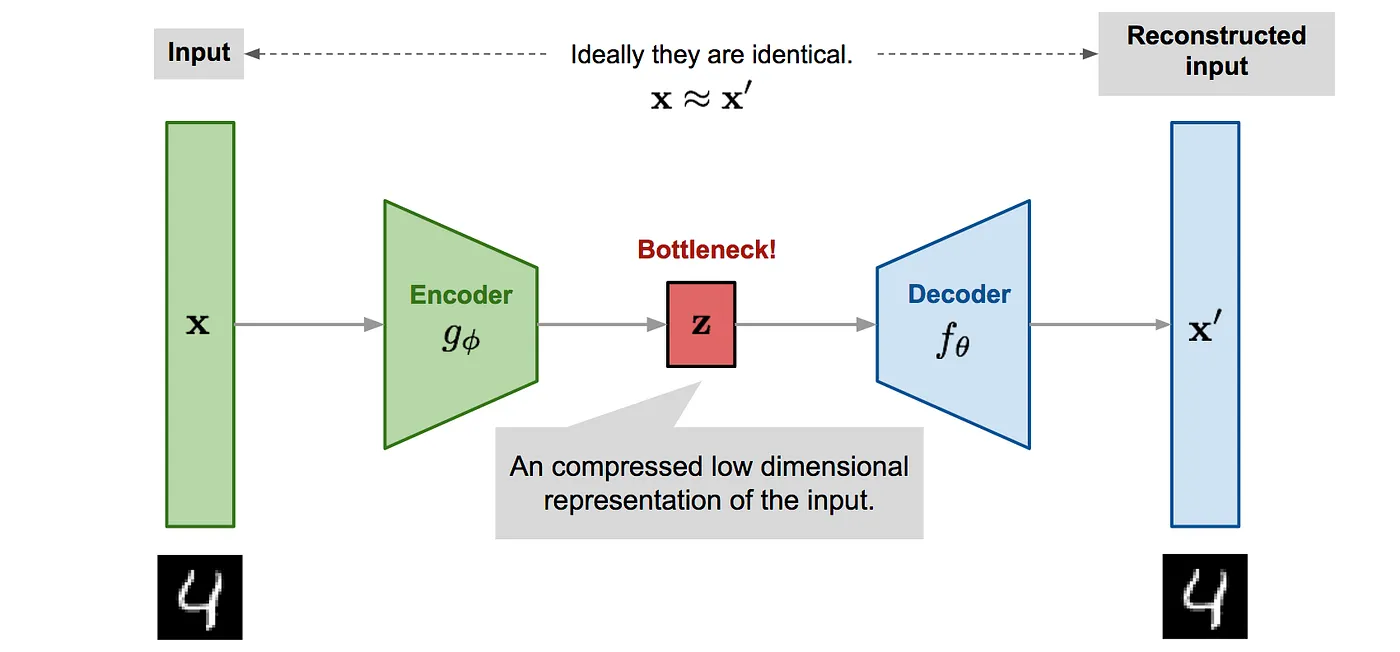

Ref: https://medium.com/@jwbtmf/lstm-autoencoder-for-anomaly-detection-for-ecg-data-5c0b07d00e50


**Encoder:**
- The encoder LSTM compresses a multivariate time series into a fixed-length representation that captures its temporal behavior.

- nn.LSTM creates an LSTM layer that will read the input sequence step by step and learn its temporal patterns.
- input_dim: Number of features at each time step: number of sensors = 21
- hidden_dim: Size of the hidden state: set as 64 (usually powers of 2). This hidden state is the compressed representation of the sequence.
- hidden_dim is a hyperparameter that controls how much temporal information the LSTM can store.
- Larger value -> more capacity to model complex dynamics
- num_layers: Number of stacked LSTM layers. More layers -> deeper temporal modeling (output of one LSTM feeds the next).
- batch_first=True sets the input tensor shape as (batch_size, sequence_length, input_dim), matcheing PyTorch DataLoader.



**Encoder:**

Input: original features per timestep

Output: compressed temporal representation (hidden state)

**Decoder**

Input: compressed representation

Output: reconstructed sequence

**Structurally similar, functionally opposite.**

- Decoder learns the temporal patterns needed to generate normal sequences, ie; about how a typical sensor evolve over time.
- It learns the ordering and dependencies between the different timesteps by first repeating the hidden state and then trying to minimize the reconstruction error.
- The hidden state is repeated to convert a fixed-length latent representation into a sequence input, enabling the LSTM decoder to reconstruct the full time series using its recurrent dynamics.

**For any nn.LSTM, PyTorch returns:**
output, (hidden, cell)

- output → hidden states at all timesteps: Timestep outputs

- hidden → final hidden state(s)

- cell → final cell state(s)

**Keep the encoder’s final hidden state to summarize the sequence, and the decoder’s timestep outputs as they are the reconstructed sequence.**



### **Implementation**

In [ ]:
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()

        self.encoder = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True
        )

        self.decoder = nn.LSTM(
            hidden_dim,
            input_dim,
            num_layers,
            batch_first=True
        )

    def forward(self, x):
        # Input x: (batch_size, seq_len, input_dim) = (64, 30, 21)

        _, (hidden, _) = self.encoder(x)
        # Final hidden state 'hidden' which is summary of the whole sequence
        # shape of hidden : (num_layers, batch_size, hidden_dim) = (1, 64, 64)

        # Repeat hidden state of last LSTM timestep times
        # hidden[-1]: shape: (64, 64)
        # unsqueeze(1) Adds a time dimension: (64, 1, 64)
        # timestep times: seq_len times: (64, 30, 64)

        hidden_repeated = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)

        # and feed to the decoder
        reconstructed, _ = self.decoder(hidden_repeated)
        # Takes the repeated latent sequence and reconstructs input(Timestep outputs)
        # by minimizing MSE(reconstructed, x)
        # (64, 30, 21)
        # ignore hidden state and cell state
        return reconstructed


In [ ]:
print(X_train.shape)

(10938, 30, 21)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(
    input_dim = X_train.shape[2],  # 21 sensors
    hidden_dim = 64
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
num_epochs = 20

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    train_loss = 0.0

    for (batch,) in train_loader:
        optimizer.zero_grad()

        outputs = model(batch)
        loss = criterion(outputs, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for (batch,) in val_loader:
            outputs = model(batch)
            loss = criterion(outputs, batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/20] Train Loss: 0.2916 | Val Loss: 0.2263
Epoch [2/20] Train Loss: 0.2340 | Val Loss: 0.2188
Epoch [3/20] Train Loss: 0.2300 | Val Loss: 0.2165
Epoch [4/20] Train Loss: 0.2284 | Val Loss: 0.2154
Epoch [5/20] Train Loss: 0.2274 | Val Loss: 0.2146
Epoch [6/20] Train Loss: 0.2268 | Val Loss: 0.2140
Epoch [7/20] Train Loss: 0.2263 | Val Loss: 0.2137
Epoch [8/20] Train Loss: 0.2257 | Val Loss: 0.2131
Epoch [9/20] Train Loss: 0.2253 | Val Loss: 0.2128
Epoch [10/20] Train Loss: 0.2249 | Val Loss: 0.2125
Epoch [11/20] Train Loss: 0.2246 | Val Loss: 0.2120
Epoch [12/20] Train Loss: 0.2243 | Val Loss: 0.2118
Epoch [13/20] Train Loss: 0.2240 | Val Loss: 0.2115
Epoch [14/20] Train Loss: 0.2236 | Val Loss: 0.2111
Epoch [15/20] Train Loss: 0.2231 | Val Loss: 0.2108
Epoch [16/20] Train Loss: 0.2226 | Val Loss: 0.2105
Epoch [17/20] Train Loss: 0.2222 | Val Loss: 0.2098
Epoch [18/20] Train Loss: 0.2218 | Val Loss: 0.2095
Epoch [19/20] Train Loss: 0.2215 | Val Loss: 0.2091
Epoch [20/20] Train L

In [ ]:
model.eval()
reconstruction_errors = []

with torch.no_grad():
    for (batch,) in val_loader:
        batch = batch.to(device)
        outputs = model(batch)

        # Mean error per sequence
        # loss = criterion(outputs, batch)
        error = torch.mean((outputs - batch) ** 2, dim=(1, 2))
        reconstruction_errors.extend(error.cpu().numpy())


In [ ]:
# setting threshold for reconstruction error to find anomaly
# use validation data errors

reconstruction_errors = np.array(reconstruction_errors)

threshold = reconstruction_errors.mean() + 3 * reconstruction_errors.std()
threshold


np.float32(0.5089314)

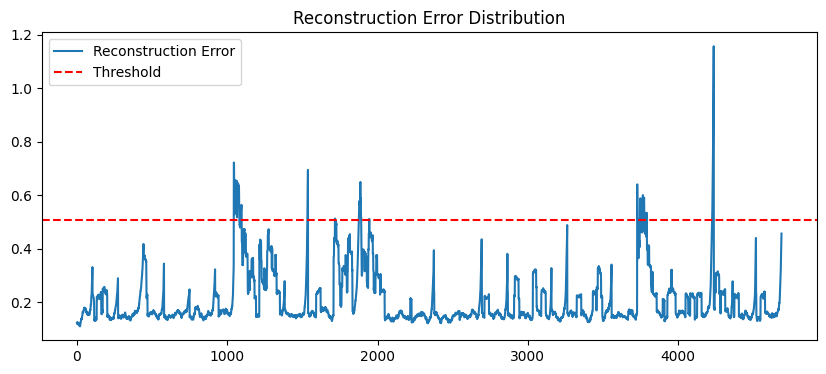

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(reconstruction_errors, label="Reconstruction Error")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()


### **Testing**

In [ ]:
test_df = pd.read_csv(
    '/content/CMaps/test_FD001.txt',
    sep=' ',
    header=None
)

test_df = test_df.iloc[:, :len(columns)]
test_df.columns = columns
test_df.head()

test_data = test_df[sensor_cols]
test_data_scaled = scaler.transform(test_data)


In [ ]:
def create_healthy_sequences(df, scaled_data, window_size=30, max_cycle=200):
    sequences = []

    for eid in df['engine_id'].unique():
        idx = (df['engine_id'] == eid) & (df['cycle'] <= max_cycle)
        engine_data = scaled_data[idx]

        for i in range(len(engine_data) - window_size):
            sequences.append(engine_data[i:i+window_size])

    return np.array(sequences)

In [ ]:
def create_test_sequences(df, scaled_data, window_size=30):
    sequences = []
    engine_ids = []
    cycle_ids = []

    for eid in df['engine_id'].unique():
        idx = df['engine_id'] == eid
        engine_data = scaled_data[idx]
        engine_cycles = df.loc[idx, 'cycle'].values

        for i in range(len(engine_data) - window_size):
            sequences.append(engine_data[i:i+window_size])
            engine_ids.append(eid)
            cycle_ids.append(engine_cycles[i + window_size])

    return np.array(sequences), engine_ids, cycle_ids

X_test, test_engine_ids, test_cycles = create_test_sequences(
    test_df, test_data_scaled, window_size=30
)

X_test.shape


(10096, 30, 21)

In [ ]:
test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

model.eval()
test_errors = []

with torch.no_grad():
    for i in range(0, len(test_tensor), 64):
        batch = test_tensor[i:i+64]
        outputs = model(batch)

        error = torch.mean((outputs - batch) ** 2, dim=(1, 2))
        test_errors.extend(error.cpu().numpy())

test_errors = np.array(test_errors)


In [ ]:
results_df = pd.DataFrame({
    'engine_id': test_engine_ids,
    'cycle': test_cycles,
    'reconstruction_error': test_errors
})

results_df['anomaly'] = results_df['reconstruction_error'] > threshold
results_df.head()


,engine_id,cycle,reconstruction_error,anomaly
0,1,31,0.132731,False
1,2,31,0.164329,False
2,2,32,0.163570,False
3,2,33,0.168662,False
4,2,34,0.165450,False


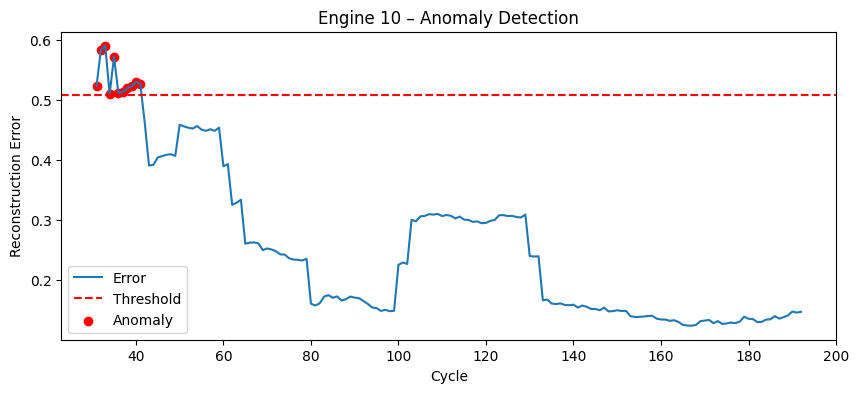

In [ ]:
# understand trend for a particular engine for all cycles

engine_to_plot = 10
engine_data = results_df[results_df['engine_id'] == engine_to_plot]

plt.figure(figsize=(10,4))
plt.plot(engine_data['cycle'], engine_data['reconstruction_error'], label='Error')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')

anomalies = engine_data[engine_data['anomaly']]
plt.scatter(
    anomalies['cycle'],
    anomalies['reconstruction_error'],
    color='red',
    label='Anomaly'
)

plt.title(f'Engine {engine_to_plot} – Anomaly Detection')
plt.xlabel('Cycle')
plt.ylabel('Reconstruction Error')
plt.legend()
plt.show()


- Engines naturally degrade toward the end.
- For several engines, anomaly scores increase sharply near the final operating cycles.
- This aligns with the dataset design, where engines progressively degrade until failure.
- The LSTM autoencoder flags late-stage behavior as anomalous because it deviates from learned healthy temporal patterns.


In [ ]:
results_df.groupby('engine_id')['anomaly'].sum()

,anomaly
engine_id,
1,0
2,0
3,0
4,0
5,0
...,...
96,0
97,0
98,0


In [ ]:
engines_with_anomaly = (
    results_df
    .groupby('engine_id')['anomaly']
    .any()
)
# No of engines that showed anomaly
engines_with_anomaly.sum()

np.int64(15)

In [ ]:
anomaly_counts_per_engine = (
    results_df
    .groupby('engine_id')['anomaly']
    .sum()
)

faulty_engine_anomaly_counts = anomaly_counts_per_engine[
    anomaly_counts_per_engine > 0
]

faulty_engine_anomaly_counts

,anomaly
engine_id,
10,11
12,5
13,16
24,24
31,2
32,9
34,22
42,1
49,3
